# Ex - Linear Regression: House Price Prediction (with Feature Engineering)

### Introduction:

This exercise uses **scikit-learn's `LinearRegression`** directly — no need to write the optimizer
by hand this time. Instead, all of our energy goes into the skills that actually separate a
mediocre model from a good one in real practice: cleaning data in the RIGHT order, choosing
features by evidence (correlation), engineering new ones, avoiding redundancy between them, and
evaluating honestly.

**Dataset:** real house sale records for **King County, Washington** (which includes Seattle) —
21,613 home sales from 2014–2015, each with its price, size, condition, location, and age.
Widely used as *the* classic real-world regression dataset. Source: public GitHub mirror of the
original Kaggle "House Sales in King County, USA" dataset.

**Goal:** predict `price`. We'll build THREE models:
1. **Simple** — just `sqft_living`
2. **Model A** — a handful of RAW columns, chosen because they correlate with price
3. **Model B** — brand-new ENGINEERED features, built on top of Model A's columns — but with any
   raw column that fed into an engineered feature **removed**, so we never feed the model the same
   information twice under two different names

Notice the ORDER of the steps below — it follows a standard preprocessing pipeline: clean the data
completely (missing values → duplicates → known errors → **outliers**) BEFORE you do anything that
depends on the data being clean, like correlation-based feature selection or feature engineering.
Doing it out of order (e.g. computing correlations before removing outliers) would mean your
feature choices are influenced by exactly the extreme, unusual rows you're trying to ignore.

Work through the steps in order — later steps depend on variables created in earlier ones.

### Step 1. Import the necessary libraries
(`numpy`, `pandas`, `matplotlib`, from scikit-learn: `train_test_split`, `LinearRegression`, `MinMaxScaler`, `r2_score`, `mean_squared_error`, `mean_absolute_percentage_error`, and from `statsmodels`: `variance_inflation_factor`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


### Step 2. Load `kc_house_data.csv` into a variable called `houses`. Print its shape and the first 5 rows.

In [2]:
houses = pd.read_csv('kc_house_data.csv')
print(houses.shape)
houses.head()

(21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Step 3. Look at the data types and general info (`.info()`).

In [3]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21609 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### Step 4. Get summary statistics for every numeric column (`.describe()`).

In [4]:
houses.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.160900e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401174e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671546e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.215000e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### Step 5. Check every column for missing values. Since `price` is our TARGET, we can't fill in a guess for a missing price — that would mean training the model on numbers we invented. Drop any rows with a missing `price` instead.

In [5]:
print(houses.isnull().sum())

houses = houses.dropna(subset=['price']).reset_index(drop=True)
print("\nShape after dropping rows with missing price:", houses.shape)

id               0
date             0
price            4
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Shape after dropping rows with missing price: (21609, 21)


### Step 6. Check the `id` column for duplicates. Investigate: are these truly duplicate ROWS (an error), or something else? Look at a couple of the repeated `id`s and their `date` column before deciding what to do.

In [6]:
print("Duplicate ids:", houses['id'].duplicated().sum())

repeated_id = houses[houses['id'].duplicated(keep=False)].sort_values('id')
repeated_id[['id','date','price']].head(6)

# Conclusion: these are the SAME house sold on two different dates (look at the `date` column) —
# a legitimate repeat sale, not a data error. Each row is a real, distinct sale event, so we
# keep both rows.

Duplicate ids: 177


,id,date,price
2497,1000102,20150422T000000,300000.0
2496,1000102,20140916T000000,280000.0
16814,7200179,20141016T000000,150000.0
16815,7200179,20150424T000000,175000.0
11434,109200390,20141020T000000,250000.0
11433,109200390,20140820T000000,245000.0


### Step 7. Investigate the `bedrooms` column with `.value_counts().sort_index()`. One value looks like an obvious data-entry error, not a real house. Find it, look at that row's other columns (sqft, bathrooms) to confirm it's a typo, and fix it (hint: it was very likely meant to be a 3).

In [7]:
print(houses['bedrooms'].value_counts().sort_index())

print(houses[houses['bedrooms'] == 33][['bedrooms','bathrooms','sqft_living','price']])
# 33 bedrooms in a 1,620 sqft house with 1.75 bathrooms is impossible — almost certainly a typo for 3.

houses.loc[houses['bedrooms'] == 33, 'bedrooms'] = 3

bedrooms
0       13
1      199
2     2758
3     9823
4     6881
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64
       bedrooms  bathrooms  sqft_living     price
15870        33       1.75         1620  640000.0


### Step 8. Fix outliers — NOW, as part of cleaning, before any correlation analysis or feature engineering touches this data.

Detect price outliers using the IQR method, computed SEPARATELY for each `grade` group (a $2,000,000 sale is very different for a grade-13 luxury build vs. a grade-5 fixer-upper). Print the bounds and outlier count per grade, then remove them.

In [8]:
def iqr_bounds(values):
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

is_outlier = pd.Series(False, index=houses.index)

for grade, group_prices in houses.groupby('grade')['price']:
    lower, upper = iqr_bounds(group_prices)
    flagged = (group_prices < lower) | (group_prices > upper)
    is_outlier.loc[group_prices.index] = flagged
    if flagged.sum() > 0:
        print(f"grade {grade:<3} bounds=[{lower:>12,.0f}, {upper:>12,.0f}]  outliers={flagged.sum():>4}  group size={len(group_prices)}")

print("\nTotal outliers:", is_outlier.sum(), "out of", len(houses))
houses = houses[~is_outlier].reset_index(drop=True)
print("Shape after removing outliers:", houses.shape)

grade 5   bounds=[      -6,125,      476,875]  outliers=  13  group size=242
grade 6   bounds=[     -12,662,      594,538]  outliers=  49  group size=2038
grade 7   bounds=[     -15,000,      785,000]  outliers= 183  group size=8979
grade 8   bounds=[      15,000,    1,015,000]  outliers= 184  group size=6066
grade 9   bounds=[     108,750,    1,342,750]  outliers= 151  group size=2615
grade 10  bounds=[      45,219,    1,972,869]  outliers=  64  group size=1134
grade 11  bounds=[      40,000,    2,696,000]  outliers=  29  group size=399
grade 12  bounds=[    -252,750,    4,421,250]  outliers=   6  group size=90
grade 13  bounds=[     337,500,    5,877,500]  outliers=   2  group size=13

Total outliers: 681 out of 21609
Shape after removing outliers: (20928, 21)


### Step 9. NOW do the EDA: a scatter plot of `sqft_living` vs `price` (on the cleaned data), and the correlation of EVERY raw numeric column with `price`, sorted by strength. We'll use this list in the next step.

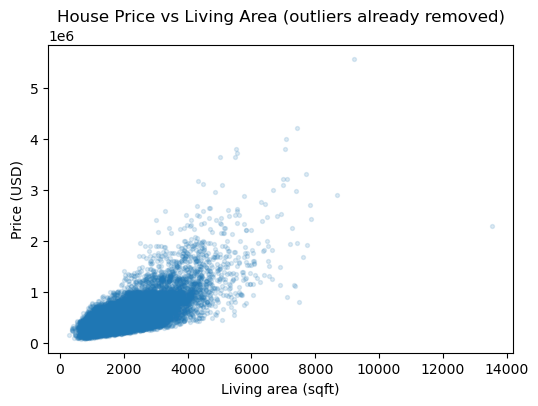

grade            0.725810
sqft_living      0.707904
sqft_above       0.621306
sqft_living15    0.599150
bathrooms        0.537414
view             0.338010
bedrooms         0.322298
floors           0.293406
sqft_basement    0.287016
waterfront       0.134709
yr_built         0.117757
sqft_lot         0.115615
sqft_lot15       0.102166
yr_renovated     0.083282
condition        0.004262
Name: price, dtype: float64

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(houses['sqft_living'], houses['price'], alpha=0.15, s=8)
plt.xlabel('Living area (sqft)')
plt.ylabel('Price (USD)')
plt.title('House Price vs Living Area (outliers already removed)')
plt.show()

raw_numeric_cols = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view',
                    'condition','grade','sqft_above','sqft_basement','yr_built','yr_renovated',
                    'sqft_living15','sqft_lot15']
houses[raw_numeric_cols + ['price']].corr()['price'].drop('price').sort_values(key=abs, ascending=False)

## 📊 Model A — pick raw features by evidence, not by guessing

### Step 10. Choose Model A's features FROM the correlation list in Step 9 — but not blindly.

Two rules:
1. **Keep only columns with |correlation| ≥ 0.25** with price (a common rule-of-thumb cutoff for "worth including").
2. **Watch out for columns that are just PIECES of another column.** `sqft_above` and `sqft_basement` both correlate with price — but `sqft_living = sqft_above + sqft_basement` EXACTLY (verify this yourself!). Including all three would mean feeding the model the same size information three times. Keep the combined `sqft_living` and drop its two parts.

We're also deliberately leaving `yr_built`, `yr_renovated`, `sqft_basement`, `lat`, `long`, and `sqft_living15` out of Model A, even though some of them are decently correlated — we're saving those columns as raw material for feature engineering in the next section.

👀 Notice: `waterfront` was one of the stronger raw correlations BEFORE we removed outliers in Step 8 — many waterfront homes are extremely expensive, so a lot of them got trimmed as per-grade outliers. Its correlation on the now-cleaned data is much weaker. This is exactly why outlier removal has to come before feature selection — do it the other way around and you'd be choosing features based on rows you're about to throw away.

In [10]:
# Verify sqft_living is exactly the sum of its two parts
print("sqft_living == sqft_above + sqft_basement for every row?",
      (houses['sqft_living'] == houses['sqft_above'] + houses['sqft_basement']).all())

model_a_features = ['grade', 'sqft_living', 'bathrooms', 'view', 'bedrooms', 'floors']
print("\nModel A features (|corr| >= 0.25, no redundant parts):", model_a_features)

sqft_living == sqft_above + sqft_basement for every row? True

Model A features (|corr| >= 0.25, no redundant parts): ['grade', 'sqft_living', 'bathrooms', 'view', 'bedrooms', 'floors']


### Step 11. Do we need to ENCODE anything before modeling? Check the data type of every Model A feature.

In [11]:
print(houses[model_a_features].dtypes)

# All six are already plain numbers (int64 / float64) straight out of the CSV — grade, view, and
# condition are pre-built numeric quality scores, not text categories like the Diamonds dataset's
# "cut"/"color"/"clarity" were. So there's nothing here to run OrdinalEncoder or OneHotEncoder on —
# encoding is a step you ADD when you need it, not a step every project needs by default.

grade            int64
sqft_living      int64
bathrooms      float64
view             int64
bedrooms         int64
floors         float64
dtype: object


## 🛠️ Feature Engineering

Now let's build NEW columns out of the raw material we deliberately held back — `yr_built`, `yr_renovated`, `sqft_basement`, `lat`/`long`, and `sqft_living15`.

### Step 12. `sale_year` and `house_age`
`date` is a text string like `"20141013T000000"` — extract the first 4 characters as `sale_year` (as an integer), then engineer `house_age` = `sale_year` − `yr_built`.

In [12]:
houses['sale_year'] = houses['date'].str[:4].astype(int)
houses['house_age'] = houses['sale_year'] - houses['yr_built']

houses[['date','sale_year','yr_built','house_age']].head()

,date,sale_year,yr_built,house_age
0,20141013T000000,2014,1955,59
1,20141209T000000,2014,1951,63
2,20150225T000000,2015,1933,82
3,20141209T000000,2014,1965,49
4,20150218T000000,2015,1987,28


### Step 13. `was_renovated` flag
`yr_renovated` is 0 for houses that were never renovated (0 is a placeholder here, not a real year!). Engineer a simple 0/1 flag `was_renovated` instead of using the raw year directly.

In [13]:
houses['was_renovated'] = (houses['yr_renovated'] > 0).astype(int)

houses['was_renovated'].value_counts()

was_renovated
0    20127
1      801
Name: count, dtype: int64

### Step 14. `has_basement` flag
Same idea: `sqft_basement` is 0 for houses with no basement. Engineer a clean 0/1 flag.

In [14]:
houses['has_basement'] = (houses['sqft_basement'] > 0).astype(int)

houses['has_basement'].value_counts()

has_basement
0    12881
1     8047
Name: count, dtype: int64

### Step 15. `bed_bath_ratio`
Engineer `bed_bath_ratio` = `bedrooms` / `bathrooms` — a single number capturing the LAYOUT of a house (lots of bedrooms but few bathrooms feels very different from a balanced layout), instead of two separate numbers. Watch out: a few houses have `bathrooms == 0`, which would divide by zero — replace those with the median ratio instead.

⚠️ This one uses `bedrooms` and `bathrooms` as its source — both are currently IN Model A. Keep that in mind for Step 19.

In [15]:
houses['bed_bath_ratio'] = houses['bedrooms'] / houses['bathrooms'].replace(0, np.nan)

median_ratio = houses['bed_bath_ratio'].median()
houses['bed_bath_ratio'] = houses['bed_bath_ratio'].fillna(median_ratio)

houses['bed_bath_ratio'].describe()

count    20928.000000
mean         1.754021
std          0.653340
min          0.000000
25%          1.333333
50%          1.600000
75%          2.000000
max          8.000000
Name: bed_bath_ratio, dtype: float64

### Step 16. `distance_to_downtown_km` — a geospatial feature!
We have `lat`/`long` for every house. Engineer the straight-line distance (in km) from each house to downtown Seattle (47.6062° N, -122.3321° W), using the **Haversine formula** (the standard formula for distance between two points on a sphere, given their latitude/longitude):

```
a = sin²(Δlat/2) + cos(lat1)·cos(lat2)·sin²(Δlong/2)
distance = 2 · R · asin(√a)      (R = 6371 km, Earth's radius)
```

In [16]:
downtown_lat, downtown_long = 47.6062, -122.3321
earth_radius_km = 6371

lat1, lat2 = np.radians(houses['lat']), np.radians(downtown_lat)
delta_lat = np.radians(downtown_lat - houses['lat'])
delta_long = np.radians(downtown_long - houses['long'])

a = np.sin(delta_lat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(delta_long/2)**2
houses['distance_to_downtown_km'] = 2 * earth_radius_km * np.arcsin(np.sqrt(a))

houses['distance_to_downtown_km'].describe()

count    20928.000000
mean        18.761650
std         10.635787
min          0.983119
25%         10.079200
50%         16.867510
75%         25.520292
max         77.093790
Name: distance_to_downtown_km, dtype: float64

### Step 17. `living_area_vs_neighbors`
`sqft_living15` is the average living area of a house's 15 nearest neighbors. Engineer `living_area_vs_neighbors` = `sqft_living` − `sqft_living15` — a positive number means this house is BIGGER than the houses around it (often a premium), negative means smaller.

⚠️ This one uses `sqft_living` as its source — and `sqft_living` is currently IN Model A. Keep that in mind for Step 19.

In [17]:
houses['living_area_vs_neighbors'] = houses['sqft_living'] - houses['sqft_living15']

houses['living_area_vs_neighbors'].describe()

count    20928.000000
mean        84.853450
std        576.547214
min      -2300.000000
25%       -220.000000
50%          0.000000
75%        300.000000
max       8690.000000
Name: living_area_vs_neighbors, dtype: float64

### Step 18. ⚠️ The trap: why NOT engineer `price_per_sqft` as a model INPUT
It's tempting to engineer `price_per_sqft = price / sqft_living` as a feature. In a markdown cell, explain in 1-2 sentences why this would be a serious mistake for a model that's trying to PREDICT `price`. (No code needed — this step is a trap to reason through, not to write.)

### Step 19. Did the engineering actually work? Print the correlation of every ENGINEERED feature (`house_age`, `was_renovated`, `has_basement`, `bed_bath_ratio`, `distance_to_downtown_km`, `living_area_vs_neighbors`) with `price`, sorted by strength.

In [18]:
engineered_features = ['house_age','was_renovated','has_basement','bed_bath_ratio',
                       'distance_to_downtown_km','living_area_vs_neighbors']

houses[engineered_features + ['price']].corr()['price'].drop('price').sort_values(key=abs, ascending=False)

living_area_vs_neighbors    0.390624
distance_to_downtown_km    -0.272488
bed_bath_ratio             -0.271411
has_basement                0.162257
house_age                  -0.117842
was_renovated               0.082907
Name: price, dtype: float64

## 📊 Model B — engineered features, WITHOUT their own sources

### Step 20. Build Model B's feature list: start from Model A's features, **remove any raw column that was used as a SOURCE to build an engineered feature** (per the ⚠️ notes in Steps 15 and 17: that's `bedrooms`, `bathrooms`, and `sqft_living`), then add all six engineered features. If we kept both a raw column AND something built directly from it, the model would be told the same information twice under two different names — that's a form of multicollinearity.

In [19]:
features_used_as_sources = ['bedrooms', 'bathrooms', 'sqft_living']

model_b_features = [f for f in model_a_features if f not in features_used_as_sources] + engineered_features
print("Model B features:", model_b_features)

Model B features: ['grade', 'view', 'floors', 'house_age', 'was_renovated', 'has_basement', 'bed_bath_ratio', 'distance_to_downtown_km', 'living_area_vs_neighbors']


### Step 21. Split into training (80%) and test (20%) sets with `train_test_split`, `random_state=1`. Call the results `train_df` and `test_df`.

In [20]:
train_df, test_df = train_test_split(houses, test_size=0.2, random_state=1)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training rows:", len(train_df))
print("Test rows:    ", len(test_df))

Training rows: 16742
Test rows:     4186


### Step 22. Fit the SIMPLE model with scikit-learn: `price ~ sqft_living`. Print the intercept and coefficient as a readable equation.

In [21]:
model_simple = LinearRegression()
model_simple.fit(train_df[['sqft_living']], train_df['price'])

print(f"Simple model equation:  price = {model_simple.intercept_:,.2f} + {model_simple.coef_[0]:,.2f} × sqft_living")

Simple model equation:  price = 23,070.83 + 237.50 × sqft_living


### Step 23. Fit **Model A** (the correlation-selected raw features from Step 10) with scikit-learn. Print every coefficient.

In [22]:
model_a = LinearRegression()
model_a.fit(train_df[model_a_features], train_df['price'])

print("Model A coefficients:")
for name, coef in zip(model_a_features, model_a.coef_):
    print(f"  {name:<15} {coef:>14,.2f}")
print(f"  {'intercept':<15} {model_a.intercept_:>14,.2f}")

Model A coefficients:
  grade               110,125.49
  sqft_living             142.63
  bathrooms           -15,372.40
  view                 58,195.04
  bedrooms            -23,472.86
  floors              -14,412.12
  intercept          -503,220.46


### Step 24. Fit **Model B** (Step 20's feature list — sources removed) with scikit-learn. Print every coefficient. Compare the signs and sizes to Model A — do they look more sensible now that nothing is duplicated?

In [23]:
model_b = LinearRegression()
model_b.fit(train_df[model_b_features], train_df['price'])

print("Model B coefficients:")
for name, coef in zip(model_b_features, model_b.coef_):
    print(f"  {name:<25} {coef:>14,.2f}")
print(f"  {'intercept':<25} {model_b.intercept_:>14,.2f}")

Model B coefficients:
  grade                         179,964.11
  view                           56,235.72
  floors                           -757.73
  house_age                       1,677.11
  was_renovated                  17,499.72
  has_basement                  -11,155.64
  bed_bath_ratio                -20,132.91
  distance_to_downtown_km        -6,166.90
  living_area_vs_neighbors           80.23
  intercept                    -798,426.20


### Step 25. Double-check Model B for leftover multicollinearity using **VIF (Variance Inflation Factor)** — a formal statistical measure (not just a guess). A rule of thumb: VIF > 5 is concerning, VIF > 10 is a real problem. Print the VIF for every Model B feature.

In [24]:
X = train_df[model_b_features].copy()
X['const'] = 1

vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(len(X.columns))],
    index=X.columns
)
vif.drop('const').sort_values(ascending=False)

house_age                   2.235688
floors                      1.853403
grade                       1.716943
bed_bath_ratio              1.434728
has_basement                1.405103
distance_to_downtown_km     1.374308
living_area_vs_neighbors    1.266155
view                        1.118560
was_renovated               1.097758
dtype: float64

## 📏 Feature scaling — not needed to FIT the model, but needed to COMPARE it

### Step 26. scikit-learn's `LinearRegression` finds the exact best-fit line no matter what scale the input columns are in — it doesn't need normalization to work correctly (that requirement is specific to gradient-descent-based optimizers, which we're not using here). BUT the RAW coefficients from Step 24 aren't fairly comparable to each other: `grade` only ranges 0–13, while `living_area_vs_neighbors` ranges over thousands of square feet — so their coefficients live on totally different scales and can't be used to rank "what matters most."

Normalize Model B's features into [0, 1] with `MinMaxScaler`, refit `LinearRegression` on the normalized values, and sort the new coefficients by size — THIS ranking is a fair comparison of feature importance.

In [25]:
scaler = MinMaxScaler()
train_features_norm = scaler.fit_transform(train_df[model_b_features])

model_b_normalized = LinearRegression()
model_b_normalized.fit(train_features_norm, train_df['price'])

importance = pd.Series(model_b_normalized.coef_, index=model_b_features).sort_values(key=abs, ascending=False)
print("Feature importance (fair, 0-1 scale comparison):")
print(importance)

Feature importance (fair, 0-1 scale comparison):
grade                       2.159569e+06
living_area_vs_neighbors    8.817592e+05
distance_to_downtown_km    -4.693672e+05
view                        2.249429e+05
house_age                   1.945452e+05
bed_bath_ratio             -1.610632e+05
was_renovated               1.749972e+04
has_basement               -1.115564e+04
floors                     -1.894327e+03
dtype: float64


### 📎 Formula reference — you'll need these for the evaluation steps

For any set of predictions, with `n` = number of rows, `actual` = real values, `predicted` = your
model's guesses, and `mean(actual)` = the average of the real values:

| Name | Formula | Plain-English meaning |
|---|---|---|
| **SST** (Total Sum of Squares) | `Σ (actual − mean(actual))²` | How spread out the real values are, ignoring the model entirely |
| **SSE** (Sum of Squared Errors) | `Σ (actual − predicted)²` | How wrong the model's predictions are (a.k.a. residual sum of squares) |
| **SSR** (Regression Sum of Squares) | `Σ (predicted − mean(actual))²` | How much of that spread the model explains |
| **Identity** | `SST = SSR + SSE` | Total spread = explained spread + unexplained spread |
| **R²** | `1 − SSE/SST` (equivalently `SSR/SST`) | Fraction of the spread the model explains (1.0 = perfect) |
| **MSE** | `SSE / n` | Average squared mistake |
| **RMSE** | `√MSE` | Average mistake, back in the SAME units as price ($) |
| **MAPE** | `mean(\|actual − predicted\| / \|actual\|) × 100` | Average mistake as a percentage of the real value |

⚠️ `SST = SSR + SSE` holds **exactly** on the data a model was fit on (the training set) — that's
a mathematical guarantee of least-squares fitting. It's usually only *approximately* true on a
held-out test set.

### Step 27. On the TRAINING set, compute SST, SSR, and SSE **by hand** for Model B (using the ORIGINAL, real-unit `model_b` from Step 24 — Step 26's normalized version was only for the importance comparison), and confirm `SST ≈ SSR + SSE`.

In [26]:
y_train = train_df['price'].values
predictions_train_b = model_b.predict(train_df[model_b_features])

sst_train = np.sum((y_train - y_train.mean()) ** 2)
sse_train = np.sum((y_train - predictions_train_b) ** 2)
ssr_train = np.sum((predictions_train_b - y_train.mean()) ** 2)

print(f"SST = {sst_train:,.0f}")
print(f"SSR = {ssr_train:,.0f}")
print(f"SSE = {sse_train:,.0f}")
print(f"SSR + SSE = {ssr_train + sse_train:,.0f}")
print("SST ≈ SSR + SSE ?", np.isclose(sst_train, ssr_train + sse_train, rtol=1e-6))

SST = 1,501,460,627,931,947
SSR = 1,001,294,798,623,352
SSE = 500,165,829,308,635
SSR + SSE = 1,501,460,627,931,987
SST ≈ SSR + SSE ? True


### Step 28. On the TEST set, write your OWN function to compute R², MSE, RMSE, and MAPE (using the formulas from the reference above — don't just call `r2_score`), then use it to evaluate all THREE models (Simple, Model A, Model B) side by side. Double-check your numbers against scikit-learn's `r2_score` / `mean_squared_error` / `mean_absolute_percentage_error` for Model B.

In [27]:
def evaluate(y_true, y_pred, label):
    sse = np.sum((y_true - y_pred) ** 2)
    sst = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - sse / sst
    mse = sse / len(y_true)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:<22} R2={r2:.4f}   MSE={mse:>15,.0f}   RMSE={rmse:>10,.0f}   MAPE={mape:>6.2f}%")
    return r2, mse, rmse, mape

y_test = test_df['price'].values

pred_simple_test = model_simple.predict(test_df[['sqft_living']])
evaluate(y_test, pred_simple_test, "Simple (sqft_living)")

pred_a_test = model_a.predict(test_df[model_a_features])
evaluate(y_test, pred_a_test, "Model A (raw, corr-picked)")

pred_b_test = model_b.predict(test_df[model_b_features])
r2_b, mse_b, rmse_b, mape_b = evaluate(y_test, pred_b_test, "Model B (engineered)")

print("\nscikit-learn check for Model B:")
print("  r2_score:", round(r2_score(y_test, pred_b_test), 4))
print("  RMSE:    ", round(np.sqrt(mean_squared_error(y_test, pred_b_test)), 0))
print("  MAPE:    ", round(mean_absolute_percentage_error(y_test, pred_b_test) * 100, 2), "%")

Simple (sqft_living)   R2=0.4919   MSE= 42,328,598,699   RMSE=   205,739   MAPE= 33.43%
Model A (raw, corr-picked) R2=0.6081   MSE= 32,647,736,411   RMSE=   180,687   MAPE= 29.38%
Model B (engineered)   R2=0.6664   MSE= 27,790,947,358   RMSE=   166,706   MAPE= 27.65%

scikit-learn check for Model B:
  r2_score: 0.6664
  RMSE:     166706.0
  MAPE:     27.65 %


### Step 29. Reflection (answer in this markdown cell, no code needed):
1. Model B has FEWER raw columns than Model A (three were removed as sources) but gained six engineered ones. Did it still win on R² and RMSE? By how much?
2. Look at the VIF values from Step 25 — are they all comfortably low now? What were the worst-offending columns before we removed `bedrooms`, `bathrooms`, and `sqft_living` (think back to Steps 15 and 17's ⚠️ warnings)?
3. From Step 26's normalized comparison, which feature has the single biggest effect on price, in a fair scale? Does that match what you'd have guessed from the raw-unit coefficients in Step 24?
4. `waterfront` was one of the strongest raw correlations before Step 8's outlier removal, but didn't make the cut afterward. Do you agree with leaving it out, or would you keep it anyway based on real-world knowledge that waterfront property carries a big premium? What does that tell you about blindly trusting a correlation threshold?
5. What's the danger of engineering a feature FROM the target, like `price_per_sqft` (Step 18)? Can you think of another feature in this dataset that would have the same problem?